# Module 1 — Ingestion: PDF → Neo4j Document Graph → One-shot RAG

**What we build in this module:**
- Parse 10-K filings with **Docling** (threaded PDF pipeline, table structure, OCR)
- Split each filing into token-aware **chunks** with `HybridChunker`
- Embed each chunk locally with a Hugging Face sentence-transformers model
- Store the result in Neo4j as a `(Company)-[:HAS_DOCUMENT]->(Document)-[:HAS_CHUNK]->(Chunk)` graph, with `Chunk.embedding` populated
- Apply schema constraints and a vector index sized to the embedding model in use
- Wire up a **one-shot RAG baseline**: embed the question, vector-search for chunks, one LLM call to answer

**Services introduced:**
- `services.pdf_parsing_service` — PDF conversion + chunking singleton
- `services.embedding_service` — local Hugging Face embedding singleton
- `services.neo4j_service` — Neo4j driver singleton
- `ingestion.document_loader.load_from_path` — PDF → `list[Document]`
- `ingestion.document_loader.add_embeddings` — `list[Document]` → same list, with `metadata["embedding"]` set
- `ingestion.graph_writer.write_documents` — `list[Document]` → Neo4j
- `ingestion.schema.apply_basic_schema` / `apply_embedding_schema` — constraints + indexes
- `qa.baseline` — one-shot RAG: `embed_question` / `retrieve_chunks` / `build_context` / `generate_answer`

## 1. Setup

In [1]:
from pathlib import Path

from financial_advisor.ingestion.document_loader import add_embeddings, load_from_path
from financial_advisor.ingestion.graph_writer import document_exists, write_documents
from financial_advisor.ingestion.schema import apply_basic_schema, apply_embedding_schema
from financial_advisor.services.embedding_service import embedding_service
from financial_advisor.services.pdf_parsing_service import pdf_parsing_service
from financial_advisor.services.neo4j_service import neo4j_service

FILINGS_DIR = Path("../data/filings")

Loading weights:   0%|          | 0/391 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/770 [00:00<?, ?it/s]

In [2]:
# Verify Neo4j connectivity before we go further
ok = neo4j_service.check_connection()
print("Neo4j connected:", ok)
assert ok, "Cannot reach Neo4j — check NEO4J_URI / credentials in .env"

[neo4j] connected — database: pack-course-bck
Neo4j connected: True


## 2. Apply Graph Schema

`apply_basic_schema()` creates uniqueness constraints on `Company.id`, `Document.id`, `Chunk.id`
plus a fulltext index on `Chunk.text`.

`apply_embedding_schema(dimensions)` creates a vector index on `Chunk.embedding`, sized to
whatever embedding model is in use — here, `embedding_service`'s Hugging Face model.

Running these multiple times is safe — all statements use `IF NOT EXISTS`.

A vector index's dimension can't be changed in place. If `chunk_embedding` already exists
from an earlier run with a different embedding model (e.g. 1536-dim Azure OpenAI vectors),
it must be dropped before `apply_embedding_schema` can recreate it at the current model's
dimension. The cell below only drops it when the dimension actually differs.

In [3]:
#this has been added to check if the existing index matches the current embedding model dimensions
existing = neo4j_service.run_query(
    "SHOW INDEXES YIELD name, options WHERE name = 'chunk_embedding' RETURN options"
)
if existing:
    existing_dims = existing[0]["options"]["indexConfig"]["vector.dimensions"]
    if existing_dims != embedding_service.dimensions:
        print(
            f"  chunk_embedding is {existing_dims}-dim, but {embedding_service.model_name} "
            f"produces {embedding_service.dimensions}-dim vectors — dropping to recreate."
        )
        neo4j_service.run_query("DROP INDEX chunk_embedding IF EXISTS")
    else:
        print("  chunk_embedding already matches the current embedding model — nothing to do.")
else:
    print("  No existing chunk_embedding index found.")

  chunk_embedding already matches the current embedding model — nothing to do.


In [4]:
apply_basic_schema()
print(f"Embedding model: {embedding_service.model_name} ({embedding_service.dimensions} dims)")
apply_embedding_schema(embedding_service.dimensions)
print("Schema applied.")

  [schema] OK  company_id
  [schema] OK  document_id
  [schema] OK  chunk_id
  [schema] OK  chunk_text
[schema] 4/4 statements applied — all good
Embedding model: BAAI/bge-m3 (1024 dims)
  [schema] OK  chunk_embedding
[schema] 1/1 statements applied — all good
Schema applied.


Let's check our database using the browser at [http://localhost:7474/browser/](http://localhost:7474/browser/)

Select the right database by using :use \`pack-course\` and run:
- SHOW CONSTRAINTS
- SHOW INDEXES

## 3. Discover Filings

The `data/filings` directory contains a few example filings in PDF format.

Filings follow the naming convention `{COMPANY}_{YEAR}_{TYPE}.pdf`  
e.g. `APPLE_2025_10K.pdf`, `3M_2025_10K.pdf`

The file name structure matters: it's used to extract the company name, the year, and the document type.

In [5]:
def parse_filing_name(stem: str) -> tuple[str, int, str] | None:
    """Return (company_id, year, filing_type) from stems like 'APPLE_2018_10K'."""
    parts = stem.split("_")
    for i, part in enumerate(parts):
        if part.isdigit() and len(part) == 4:
            return "_".join(parts[:i]) or stem, int(part), parts[i + 1] if i + 1 < len(parts) else ""
    return None


pdfs = sorted(FILINGS_DIR.glob("**/*.pdf"))
filings = []
for pdf in pdfs:
    parsed = parse_filing_name(pdf.stem)
    if parsed:
        company_id, year, filing_type = parsed
        filings.append({"path": pdf, "company_id": company_id, "year": year, "filing_type": filing_type})
        print(f"  {pdf.name}  →  company={company_id}, year={year}, type={filing_type}")
    else:
        print(f"  [SKIP] {pdf.name} — cannot parse company/year")

print(f"\n{len(filings)} filing(s) ready to ingest.")

  3M_2024_10K.pdf  →  company=3M, year=2024, type=10K
  3M_2025_10K.pdf  →  company=3M, year=2025, type=10K
  APPLE_2024_10K.pdf  →  company=APPLE, year=2024, type=10K
  APPLE_2025_10K.pdf  →  company=APPLE, year=2025, type=10K

4 filing(s) ready to ingest.


## 4. Convert a Single Filing with Docling

Before bulk-ingesting everything, let's inspect one filing step by step  
to understand what Docling extracts and how the chunker splits the document.

In [6]:
# Pick the first filing for the walkthrough
sample = filings[1]
print(f"Processing: {sample['path'].name}")


Processing: 3M_2025_10K.pdf


In [7]:
# Convert the PDF to text and extract metadata
conv_result = pdf_parsing_service.convert_pdf(sample["path"])
print("Conversion status:", getattr(conv_result, "status", "ok"))

Conversion status: ConversionStatus.SUCCESS


In [8]:
# Document-level metadata extracted from the PDF
meta = pdf_parsing_service.extract_metadata(conv_result, sample["path"])
for k, v in meta.items():
    print(f"  {k}: {v}")

  doc_name: 3M_2025_10K.pdf
  title: 3M_2025_10K
  source: /Users/ale/Dropbox/prj-graphaware/packt-course-beyond-graphrag/data/filings/3M_2025_10K.pdf
  format: pdf
  total_pages: 158
  author: None
  subject: None
  creation_date: None
  keywords: None


In [9]:
# Chunk the document and inspect the first few chunks
chunks = pdf_parsing_service.chunk_document(conv_result)
print(f"Total chunks: {len(chunks)}\n")

for i, chunk in enumerate(chunks[:5]):
    print(f"################# Chunk {i} (pages {chunk.pages}) #################")
    print(chunk.text[:400])
    print("#################"*10 + "\n")

Total chunks: 213

################# Chunk 0 (pages [1]) #################
SECURITIES AND EXCHANGE COMMISSION
Washington, D.C. 20549
##########################################################################################################################################################################

################# Chunk 1 (pages [1]) #################
FORM 10-K
☒ ANNUAL REPORT PURSUANT TO SECTION 13 OR 15(d) OF THE SECURITIES EXCHANGE ACT OF 1934
For the fiscal year ended December 31, 2025
or
o TRANSITION REPORT PURSUANT TO SECTION 13 OR 15(d) OF THE SECURITIES EXCHANGE ACT OF 1934
For the transition period from __________ to __________
State of Incorporation: Delaware
##########################################################################################################################################################################

################# Chunk 2 (pages [1]) #################
DOCUMENTS INCORPORATED BY REFERENCE
Parts of the Company's definitive proxy statement (

#### 4a. Sanity Check — View the Source Page

The snippets above are text pulled out of the PDF by Docling. To eyeball whether the
extraction is faithful, render the actual first page of the source file — `pypdfium2`
comes in transitively via Docling's PDF backend, so no extra dependency is needed.

Page 1 of 3M_2025_10K.pdf — 1224x1584px


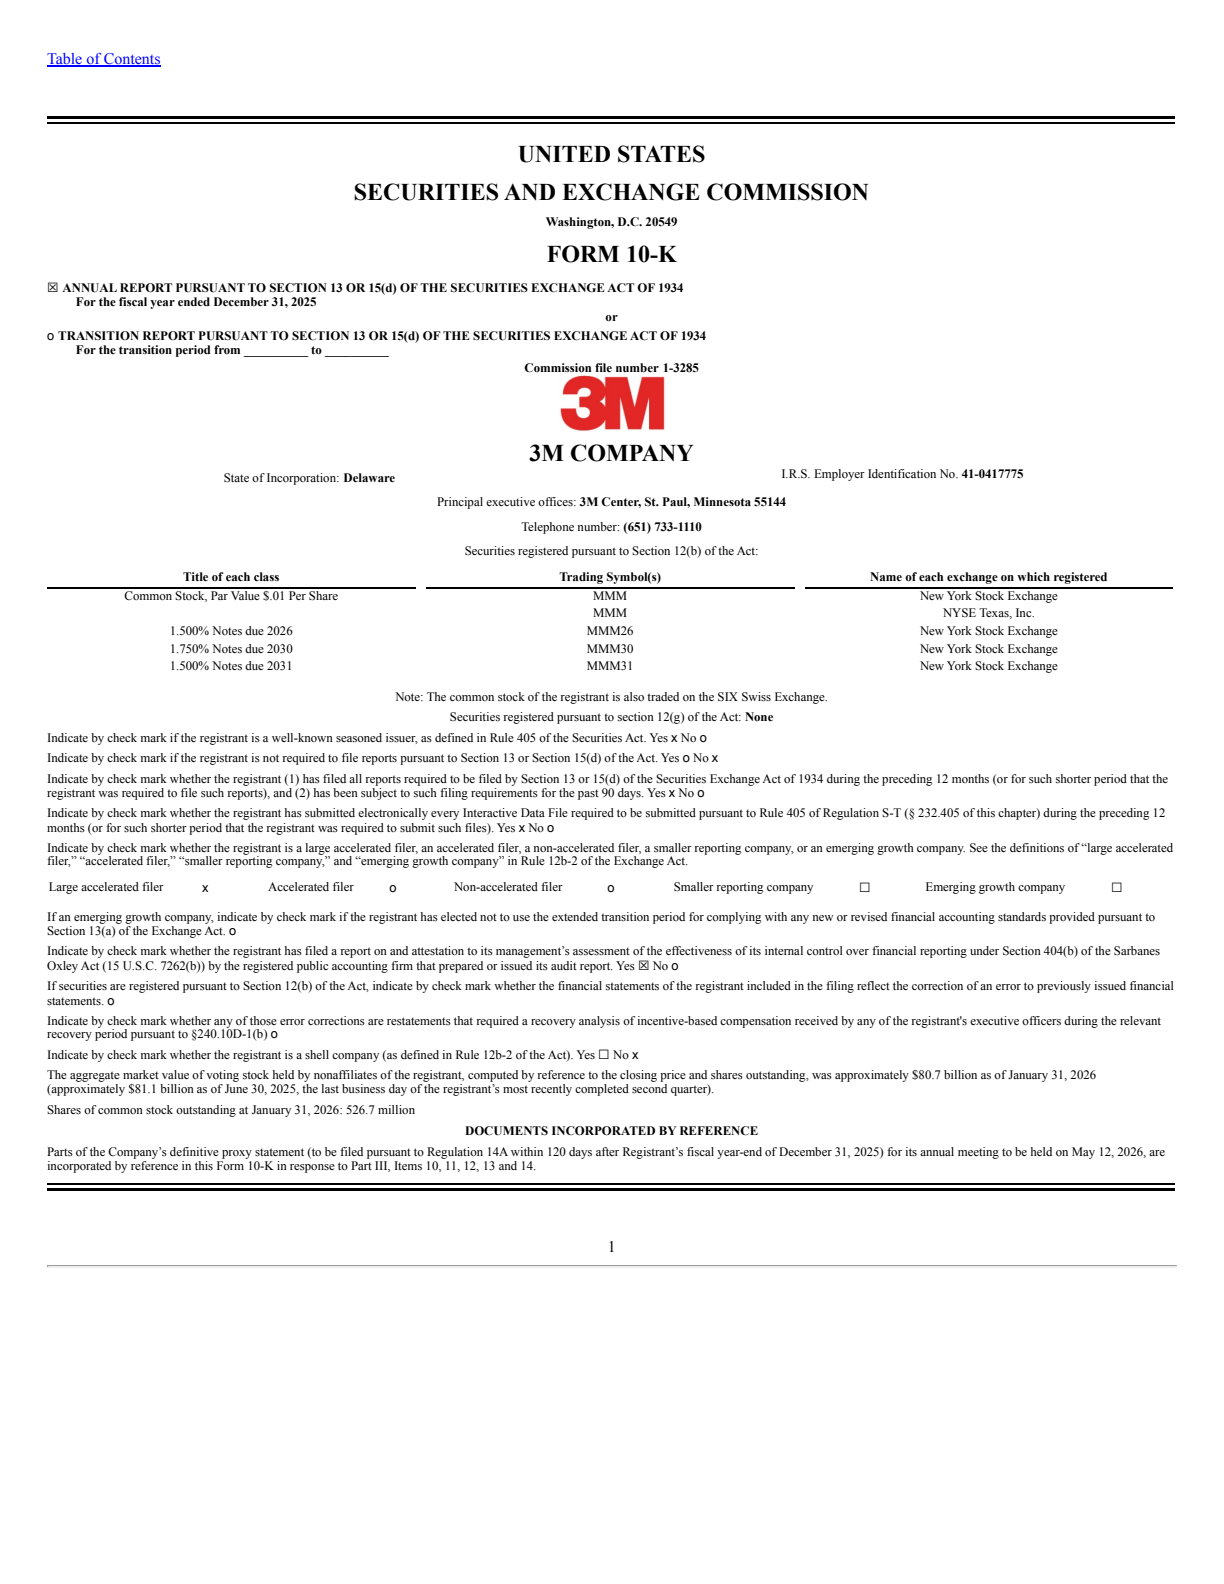

In [10]:
import pypdfium2 as pdfium

pdf_doc = pdfium.PdfDocument(sample["path"])
page_image = pdf_doc[0].render(scale=2.0).to_pil()
print(f"Page 1 of {sample['path'].name} — {page_image.size[0]}x{page_image.size[1]}px")
page_image

## 5. Load a Single Filing into Neo4j

`load_from_path` wraps conversion + chunking and returns LangChain `Document` objects  
ready to be passed to `write_documents`.

### Create the Documents array 
Create the Document object and add to the array of documents to be stored in neo4j

In [11]:
from langchain_core.documents import Document

documents = [
        Document(
            page_content=chunk.text,
            metadata={
                "company_id": sample["company_id"],
                "year": sample["year"],
                "chunk_index": i,
                "pages": chunk.pages,
                **meta,
            },
        )
        for i, chunk in enumerate(chunks)
    ]
print(f"Documents (chunks) produced: {len(documents)}")

# Inspect metadata on one document
print("\nSample metadata:")
for k, v in documents[0].metadata.items():
    print(f"  {k}: {v}")

Documents (chunks) produced: 213

Sample metadata:
  company_id: 3M
  year: 2025
  chunk_index: 0
  pages: [1]
  doc_name: 3M_2025_10K.pdf
  title: 3M_2025_10K
  source: /Users/ale/Dropbox/prj-graphaware/packt-course-beyond-graphrag/data/filings/3M_2025_10K.pdf
  format: pdf
  total_pages: 158
  author: None
  subject: None
  creation_date: None
  keywords: None


In [ ]:
# SKIP because it is already done in the previous step
documents = load_from_path(
    sample["path"],
    company_id=sample["company_id"],
    year=sample["year"],
)
print(f"Documents (chunks) produced: {len(documents)}")

# Inspect metadata on one document
print("\nSample metadata:")
for k, v in documents[0].metadata.items():
    print(f"  {k}: {v}")

### Compute Embeddings

`add_embeddings` batches every chunk's text through `embedding_service` in one call and
sets `metadata["embedding"]` on each `Document` in place.

In [12]:
documents = add_embeddings(documents)

sample_embedding = documents[0].metadata["embedding"]
print(f"Vector length: {len(sample_embedding)}")
print(f"First 5 values: {sample_embedding[:5]}")

Vector length: 1024
First 5 values: [-0.01064300537109375, 0.01061248779296875, -0.033294677734375, -0.0035305023193359375, -0.03826904296875]


### Store in neo4j

In [13]:
# Write to Neo4j
write_documents(documents, company_id=sample["company_id"])
print("Done.")

  Wrote 213 chunks for 3M_2025_10K.pdf
Done.


## 6. Verify — Query the Graph

Check that the nodes and relationships were created correctly.

In [14]:
# Node counts
counts = neo4j_service.run_query("""
    MATCH (c:Company) WITH count(c) AS companies
    MATCH (d:Document) WITH companies, count(d) AS documents
    MATCH (ch:Chunk)   RETURN companies, documents, count(ch) AS chunks
""")
print(counts[0])

{'companies': 1, 'documents': 1, 'chunks': 213}


In [15]:
# Sample the graph: one company, its documents, first 3 chunks
rows = neo4j_service.run_query("""
    MATCH (c:Company)-[:HAS_DOCUMENT]->(d:Document)-[:HAS_CHUNK]->(ch:Chunk)
    WHERE c.id = $company_id
    RETURN c.id AS company, d.doc_name AS document, d.total_pages AS pages,
           ch.idx AS chunk_idx, ch.pages AS chunk_pages,
           size(ch.embedding) AS embedding_size,
           left(ch.text, 120) AS snippet
    ORDER BY ch.idx
    LIMIT 3
""", {"company_id": sample["company_id"]})

for row in rows:
    print(row)

{'company': '3M', 'document': '3M_2025_10K.pdf', 'pages': 158, 'chunk_idx': 0, 'chunk_pages': [1], 'embedding_size': 1024, 'snippet': 'SECURITIES AND EXCHANGE COMMISSION\nWashington, D.C. 20549'}
{'company': '3M', 'document': '3M_2025_10K.pdf', 'pages': 158, 'chunk_idx': 1, 'chunk_pages': [1], 'embedding_size': 1024, 'snippet': 'FORM 10-K\n☒ ANNUAL REPORT PURSUANT TO SECTION 13 OR 15(d) OF THE SECURITIES EXCHANGE ACT OF 1934\nFor the fiscal year end'}
{'company': '3M', 'document': '3M_2025_10K.pdf', 'pages': 158, 'chunk_idx': 2, 'chunk_pages': [1], 'embedding_size': 1024, 'snippet': "DOCUMENTS INCORPORATED BY REFERENCE\nParts of the Company's definitive proxy statement (to be filed pursuant to Regulatio"}


In [16]:
# Get more chunks for the same company
rows = neo4j_service.run_query("""
    MATCH (ch:Chunk)
    WHERE ch.company_id = $company_id
    RETURN ch.company_id AS company,
           ch.idx AS chunk_idx, ch.pages AS chunk_pages,
           ch.embedding AS embedding,
           left(ch.text, 120) AS snippet
    ORDER BY ch.idx
    LIMIT 3
""", {"company_id": sample["company_id"]})

for row in rows:
    print(f"Company: {row['company']}, chunk {row['chunk_idx']} (pages {row['chunk_pages']}):")
    print(row["snippet"]+"\n")
    print(f"Embedding {row['embedding'][:5]}\n")

Company: 3M, chunk 0 (pages [1]):
SECURITIES AND EXCHANGE COMMISSION
Washington, D.C. 20549

Embedding [-0.01064300537109375, 0.01061248779296875, -0.033294677734375, -0.0035305023193359375, -0.03826904296875]

Company: 3M, chunk 1 (pages [1]):
FORM 10-K
☒ ANNUAL REPORT PURSUANT TO SECTION 13 OR 15(d) OF THE SECURITIES EXCHANGE ACT OF 1934
For the fiscal year end

Embedding [-0.018402099609375, 0.009002685546875, -0.0105743408203125, 0.007328033447265625, -0.047271728515625]

Company: 3M, chunk 2 (pages [1]):
DOCUMENTS INCORPORATED BY REFERENCE
Parts of the Company's definitive proxy statement (to be filed pursuant to Regulatio

Embedding [-0.0283966064453125, 0.0164031982421875, -0.0062103271484375, -0.001094818115234375, -0.048309326171875]



Page 1 of 3M_2025_10K.pdf — 1224x1584px


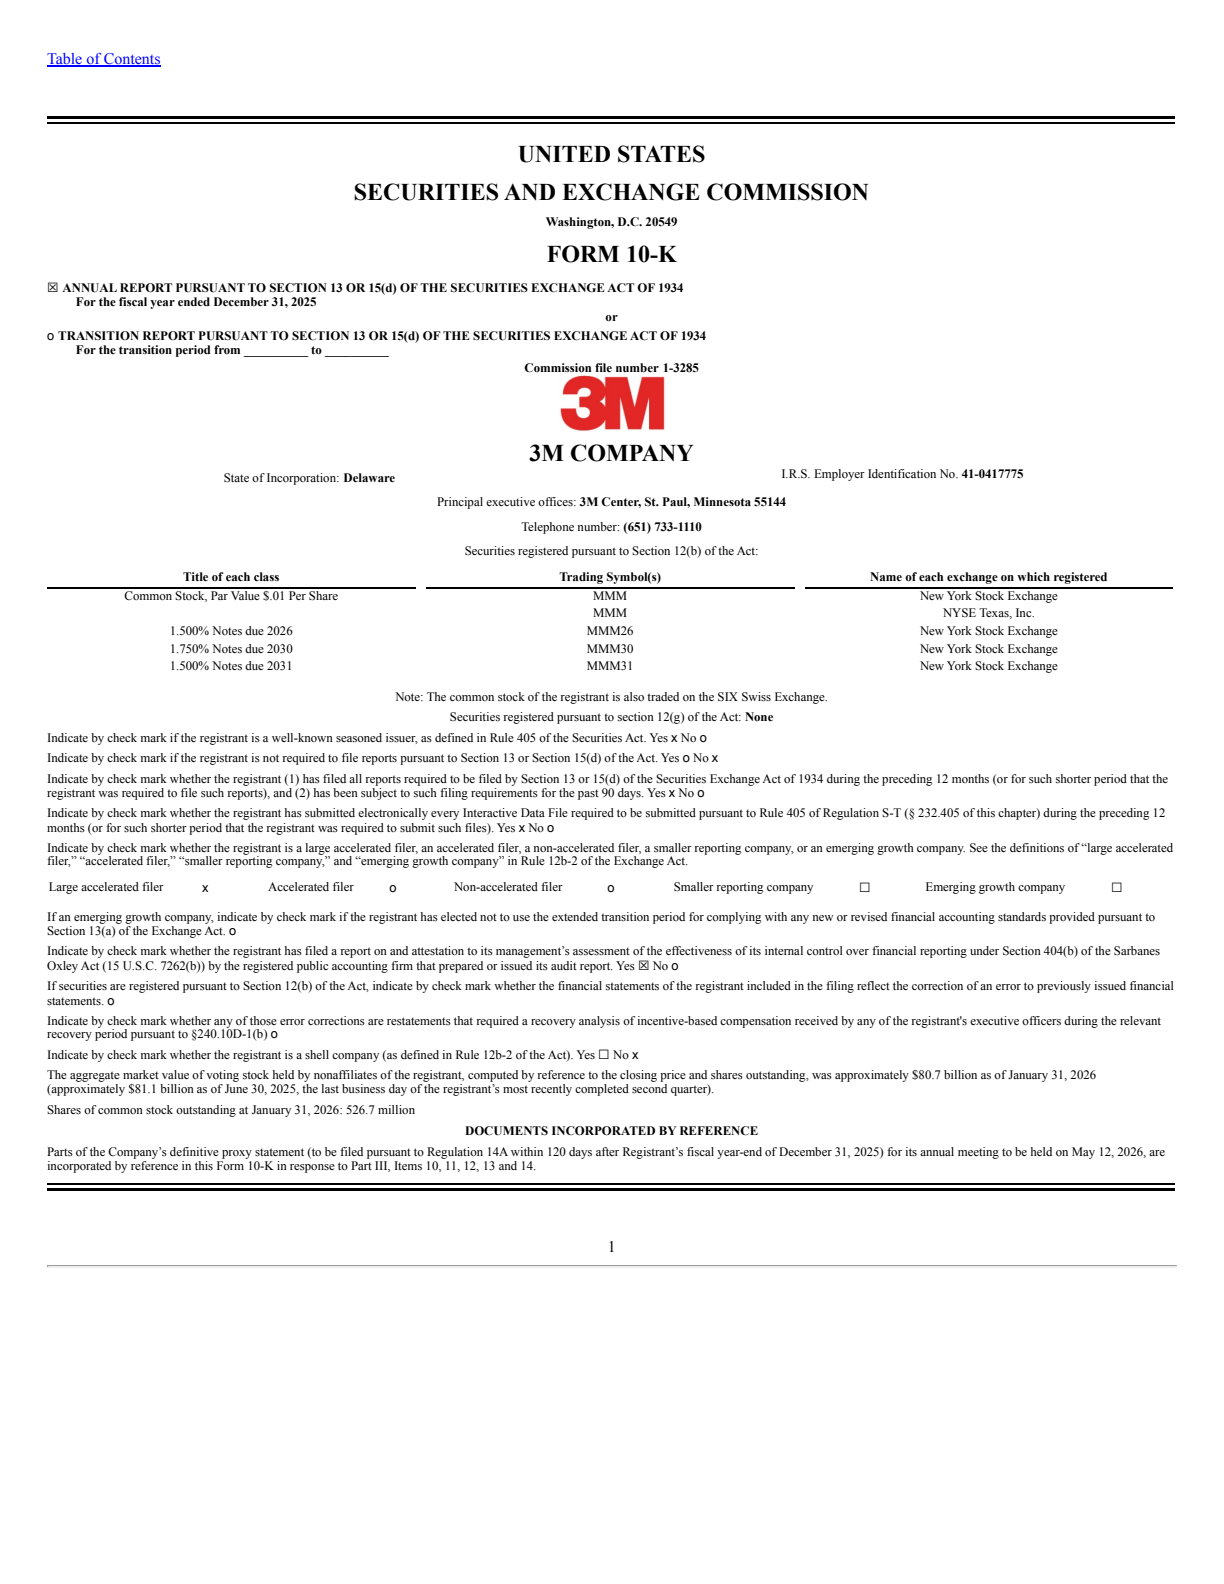

In [17]:
import pypdfium2 as pdfium

pdf_doc = pdfium.PdfDocument(sample["path"])
page_image = pdf_doc[0].render(scale=2.0).to_pil()
print(f"Page 1 of {sample['path'].name} — {page_image.size[0]}x{page_image.size[1]}px")
page_image

Let's check our database using the browser at [http://localhost:7474/browser/](http://localhost:7474/browser/)

Run: 

```
MATCH p=(company:Company)-[:HAS_DOCUMENT]->(document:Document)-[:HAS_CHUNK]->( :Chunk)
RETURN *
limit 20
```

## 7. Ingest All Filings

Now run the full loop over every PDF found in `data/filings/`.  
Already-ingested documents are skipped automatically (idempotent).

In [18]:
import time

for filing in filings:
    if document_exists(filing["company_id"], filing["path"].name):
        print(f"\n[{filing['company_id']}] {filing['path'].name} — already in graph, skipping")
        continue

    print(f"\n[{filing['company_id']}] {filing['path'].name} (year={filing['year']})")

    t0 = time.perf_counter()
    docs = load_from_path(
        filing["path"],
        company_id=filing["company_id"],
        year=filing["year"],
    )
    t1 = time.perf_counter()
    print(f"  load_from_path: {t1 - t0:.1f}s")

    if not docs:
        print("  No chunks produced — skipping.")
        continue
    print(f"  {len(docs)} chunks extracted")

    docs = add_embeddings(docs)
    t2 = time.perf_counter()
    print(f"  add_embeddings: {t2 - t1:.1f}s")

    write_documents(docs, company_id=filing["company_id"])
    t3 = time.perf_counter()
    print(f"  write_documents: {t3 - t2:.1f}s")

    print(f"  total: {t3 - t0:.1f}s")

print("\nAll filings processed.")


[3M] 3M_2024_10K.pdf (year=2024)
  load_from_path: 26.7s
  271 chunks extracted
  add_embeddings: 13.0s
  Wrote 271 chunks for 3M_2024_10K.pdf
  write_documents: 0.7s
  total: 40.4s

[3M] 3M_2025_10K.pdf — already in graph, skipping

[APPLE] APPLE_2024_10K.pdf (year=2024)
  load_from_path: 12.4s
  257 chunks extracted
  add_embeddings: 8.7s
  Wrote 257 chunks for APPLE_2024_10K.pdf
  write_documents: 0.7s
  total: 21.8s

[APPLE] APPLE_2025_10K.pdf (year=2025)
  load_from_path: 9.0s
  214 chunks extracted
  add_embeddings: 5.7s
  Wrote 214 chunks for APPLE_2025_10K.pdf
  write_documents: 0.6s
  total: 15.2s

All filings processed.


In [19]:
# Final count across all companies
summary = neo4j_service.run_query("""
    MATCH (c:Company)-[:HAS_DOCUMENT]->(d:Document)
    OPTIONAL MATCH (d)-[:HAS_CHUNK]->(ch:Chunk)
    RETURN c.id AS company, d.doc_name AS document,
           d.total_pages AS pages, count(ch) AS chunks
    ORDER BY company, document
""")

for row in summary:
    print(row)

{'company': '3M', 'document': '3M_2024_10K.pdf', 'pages': 182, 'chunks': 271}
{'company': '3M', 'document': '3M_2025_10K.pdf', 'pages': 158, 'chunks': 213}
{'company': 'APPLE', 'document': 'APPLE_2024_10K.pdf', 'pages': 121, 'chunks': 257}
{'company': 'APPLE', 'document': 'APPLE_2025_10K.pdf', 'pages': 80, 'chunks': 214}


Let's check our database using the browser at [http://localhost:7474/browser/](http://localhost:7474/browser/)


## 8. One-Shot RAG Baseline — Ask a Question

The simplest retrieval-augmented pattern: embed the question with the same model used
for the chunks, pull back the top-k most similar chunks from the `chunk_embedding`
vector index, and hand them to the LLM in a single call. No tool use, no iteration —
one retrieval, one generation.

Implementation lives in `financial_advisor.qa.baseline`, split into four steps so each
can be inspected on its own: `embed_question`, `retrieve_chunks`, `build_context`,
`generate_answer`.

In [20]:
from financial_advisor.qa.baseline import (
    build_context,
    embed_question,
    generate_answer,
    retrieve_chunks,
)

### 8a. Step by Step, on One Question

In [21]:
question = "What is 3M's principal executive office address?"
print(f"Question: {question}")

Question: What is 3M's principal executive office address?


In [22]:
# Step 1 — embed the question with the same model used for chunks
query_vector = embed_question(question)
print(f"Vector length: {len(query_vector)}")
print(f"First 5 values: {query_vector[:5]}")

Vector length: 1024
First 5 values: [-0.035369873046875, -0.032562255859375, -0.0139007568359375, -0.048858642578125, -0.006557464599609375]


In [23]:
# Step 2 — vector search: top-k chunks by cosine similarity
retrieved = retrieve_chunks(query_vector, k=5)
print(f"Retrieved {len(retrieved)} chunks:\n")
for chunk in retrieved:
    print("#####################")
    print(f"  Score: {chunk.score:.3f}, Doc: {chunk.doc_id}, Chunk ID: {chunk.id}")
    print(f"    {chunk.text[:500]}")
    print("#####################\n")

Retrieved 5 chunks:

#####################
  Score: 0.841, Doc: 3M/3M_2024_10K.pdf, Chunk ID: 3M/3M_2024_10K.pdf/3
    3M COMPANY
Principal executive offices: 3M Center, St. Paul, Minnesota 55144

## Telephone number: (651) 733-1110

Securities registered pursuant to Section 12(b) of the Act:

Title of each class

Trading Symbol(s)

Name of each exchange on which registered

Common Stock, Par Value $.01 Per Share

MMM

New York Stock Exchange

MMM

Chicago Stock Exchange, Inc.

1.500% Notes due 2026

MMM26

New York Stock Exchange

1.750% Notes due 2030

MMM30

New York Stock Exchange

1.500% Notes due 2031

MMM
#####################

#####################
  Score: 0.816, Doc: 3M/3M_2024_10K.pdf, Chunk ID: 3M/3M_2024_10K.pdf/157
    Item 10. Directors, Executive Officers and Corporate Governance
The information relating to directors and nominees of 3M is set forth under the caption 'Proposal No. 1' in 3M's proxy statement for its annual meeting of stockholders to be held on May 13, 202

In [24]:
# Step 3 — stitch the retrieved chunks into a single context block
context = build_context(retrieved)
print(f"Context: {len(context)} chars from {len(retrieved)} chunks\n")
print(context[:500])

Context: 5592 chars from 5 chunks

[3M/3M_2024_10K.pdf | score=0.841]
3M COMPANY
Principal executive offices: 3M Center, St. Paul, Minnesota 55144

## Telephone number: (651) 733-1110

Securities registered pursuant to Section 12(b) of the Act:

Title of each class

Trading Symbol(s)

Name of each exchange on which registered

Common Stock, Par Value $.01 Per Share

MMM

New York Stock Exchange

MMM

Chicago Stock Exchange, Inc.

1.500% Notes due 2026

MMM26

New York Stock Exchange

1.750% Notes due 2030

MMM30

New York Stock E


In [25]:
# Step 4 — one LLM call over the retrieved context: the "one shot" in one-shot RAG
answer = generate_answer(question, retrieved)
print(f"Answer:\n{answer}")

Answer:
3M's principal executive office address is **3M Center, St. Paul, Minnesota 55144**.


In [26]:
question = "What is Apple's principal executive office address?"
print(f"Question: {question}")
# Step 1 — embed the question with the same model used for chunks
query_vector = embed_question(question)
print(f"Vector length: {len(query_vector)}")
print(f"First 5 values: {query_vector[:5]}")

# Step 2 — vector search: top-k chunks by cosine similarity
retrieved = retrieve_chunks(query_vector, k=5)
print(f"Retrieved {len(retrieved)} chunks:\n")
for chunk in retrieved:
    print("#####################")
    print(f"  Score: {chunk.score:.3f}, Doc: {chunk.doc_id}, Chunk ID: {chunk.id}")
    print(f"    {chunk.text[:500]}")
    print("#####################\n")

# Step 3 — stitch the retrieved chunks into a single context block
context = build_context(retrieved)
print(f"Context: {len(context)} chars from {len(retrieved)} chunks\n")
print(context[:500]+"\n\n...")

# Step 4 — one LLM call over the retrieved context: the "one shot" in one-shot RAG
answer = generate_answer(question, retrieved)
print(f"Answer:\n{answer}")



Question: What is Apple's principal executive office address?
Vector length: 1024
First 5 values: [-0.009613037109375, -0.0140533447265625, -0.03887939453125, -0.00952911376953125, -0.0134429931640625]
Retrieved 5 chunks:

#####################
  Score: 0.793, Doc: APPLE/APPLE_2025_10K.pdf, Chunk ID: APPLE/APPLE_2025_10K.pdf/2
    Apple Inc.
(Exact name of Registrant as specified in its charter)
California
94-2404110
(State or other jurisdiction of incorporation or organization)
(I.R.S. Employer Identification No.)
One Apple Park Way Cupertino, California
95014
(Address of principal executive offices)
(Zip Code)
(408) 996-1010
(Registrant's telephone number, including area code)
Securities registered pursuant to Section 12(b) of the Act:
Title of each class
Trading symbol(s)
Name of each exchange on which registered
Commo
#####################

#####################
  Score: 0.788, Doc: APPLE/APPLE_2024_10K.pdf, Chunk ID: APPLE/APPLE_2024_10K.pdf/2
    Apple Inc.
(Exact name of Registr

### 8b. A Few More Questions — Easy vs. Harder

Single-chunk factual questions tend to work well: the right chunk scores highest and the
LLM just reads it off — even year-over-year comparisons *within* one company often work,
since 10-Ks present multi-year figures side by side in the same table/chunk. Where the
one-shot pattern starts to visibly struggle is when the needed facts live in *separate*
chunks with a shared, fixed top-k retrieval budget — e.g. a detail reported once per
filing (not in a joint comparison table) can lose out to more broadly-relevant chunks —
or when reasoning has to span two different companies' documents entirely. There's no
mechanism here to run a second, more targeted retrieval or reconcile partial results.
That gap is exactly what Module 2's agentic loop is built to close.

In [27]:
EXAMPLE_QUESTIONS = [
    "What was Apple's total revenue in fiscal year 2024?",  # single-chunk factual — easy, numeric
    "What was 3M's total revenue in fiscal year 2025?",  # single-chunk factual — easy, numeric
    "Who is 3M's CEO according to the 2024 10-K filing?",  # single-chunk factual — easy
    "Who is Apple's CEO according to the 2025 10-K filing?",  # single-chunk factual — easy
    "How did the number of 3M's U.S. manufacturing facilities change between the 2024 "
    "and 2025 10-K filings?",  # spans both 3M filings — each year states its count once, in
    # Item 2 Properties, not in a joint comparison table, so it competes on equal footing
    # with everything else for a fixed top-5 budget and reliably gets crowded out
    "Compare 3M's and Apple's approach to research and development investment, "
    "based on their 2025 10-Ks.",  # cross-document, cross-company synthesis — hard, left last since one-shot RAG can't reliably answer this
]

for q in EXAMPLE_QUESTIONS:
    print(f"\n{'=' * 80}")
    print(f"Q: {q}\n")

    chunks = retrieve_chunks(embed_question(q), k=5)
    print("Retrieved:")
    for chunk in chunks:
        print(f"  [{chunk.score:.3f}] {chunk.doc_id}")

    answer = generate_answer(q, chunks)
    print(f"\nA: {answer}")


Q: What was Apple's total revenue in fiscal year 2024?

Retrieved:
  [0.823] APPLE/APPLE_2024_10K.pdf
  [0.820] APPLE/APPLE_2024_10K.pdf
  [0.814] APPLE/APPLE_2025_10K.pdf
  [0.804] APPLE/APPLE_2024_10K.pdf
  [0.794] APPLE/APPLE_2024_10K.pdf

A: Apple’s total net sales (revenue) in fiscal year 2024 were **$391,035 million**.

Q: What was 3M's total revenue in fiscal year 2025?

Retrieved:
  [0.841] 3M/3M_2024_10K.pdf
  [0.838] 3M/3M_2025_10K.pdf
  [0.836] 3M/3M_2025_10K.pdf
  [0.832] 3M/3M_2024_10K.pdf
  [0.828] 3M/3M_2025_10K.pdf

A: 3M's total revenue in fiscal year 2025 was **$24,948 million**.

Q: Who is 3M's CEO according to the 2024 10-K filing?

Retrieved:
  [0.835] 3M/3M_2024_10K.pdf
  [0.815] 3M/3M_2025_10K.pdf
  [0.801] 3M/3M_2025_10K.pdf
  [0.799] 3M/3M_2024_10K.pdf
  [0.797] 3M/3M_2024_10K.pdf

A: According to the 2024 10-K filing, 3M’s CEO is **William M. Brown**.

Q: Who is Apple's CEO according to the 2025 10-K filing?

Retrieved:
  [0.801] APPLE/APPLE_2025_10K.pdf
  [0